In [1]:
# Setup environment for inference (centralized colors from config)
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))
import torch
torch.set_warn_always(False)

from src.visualization import setup_inference_environment

env = setup_inference_environment()
device = env['device']
EQUIPMENT_NAMES = env['equipment_names']
EQUIPMENT_COLORS = env['equipment_colors']  # from config
KEYPOINT_COLORS = env['keypoint_colors']    # from config

print("✓ Environment ready for inference")

✓ Environment ready for inference


In [ ]:
# Run Inference with Equipment Detection Model on a Random Image in Test Dataset
from src.inference import load_equipment_detector
from src.visualization import run_equipment_detection_inference
from src.config import EQUIPMENT_DETECTION_CONFIG, EQUIPMENT_DETECTION_IMAGES_VAL

equip_detector = load_equipment_detector(device)

val_dir = EQUIPMENT_DETECTION_IMAGES_VAL
gt_boxes, pred_boxes = run_equipment_detection_inference(
    equip_detector, val_dir, EQUIPMENT_DETECTION_CONFIG,
    0, 0, EQUIPMENT_NAMES, EQUIPMENT_COLORS, device
)

HRNet output channels: 256
✓ Transformer keypoint detector loaded from runs/transformer_keypoint_detection/weights/best.pth
Image: MIJC006_062_1_Main_transformer1.jpg
Path: datasets/transformer_keypoint_detection/images/val/MIJC006_062_1_Main_transformer1.jpg
Image dimensions: 254x339

Running transformer keypoint inference...


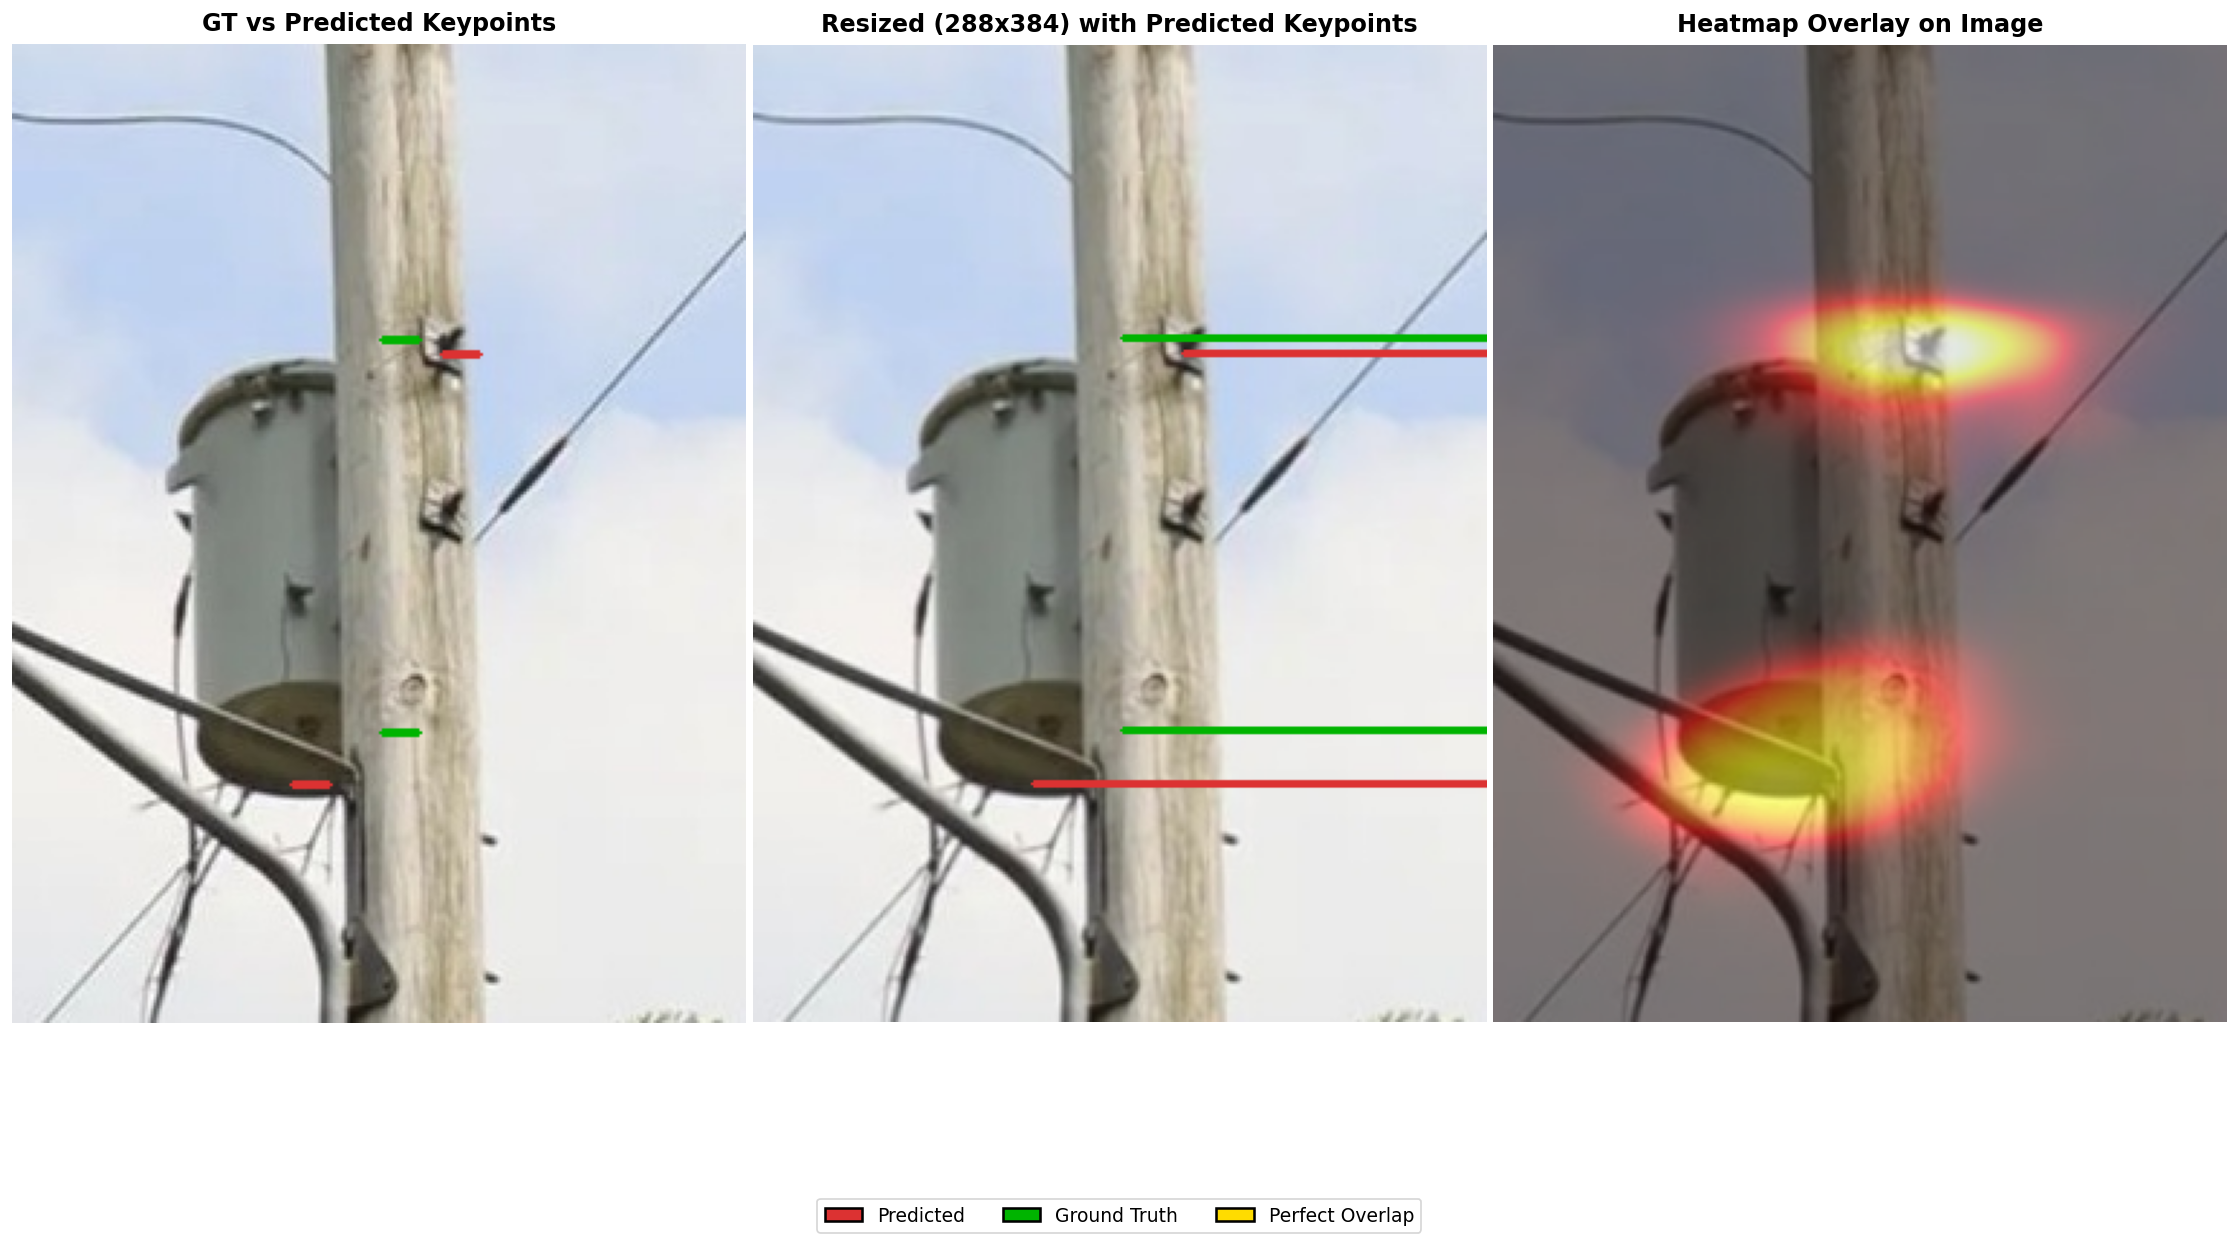

Image: MIJC006_062_1_Main_transformer1.jpg
Path: datasets/transformer_keypoint_detection/images/val/MIJC006_062_1_Main_transformer1.jpg
GT: 0 bboxes, 2 keypoints
Pred: 0 detections, 2 keypoints
  Pred kp 1: top_bolt conf=0.897 error=0.728 in
  Pred kp 2: bottom conf=0.706 error=2.576 in


In [43]:
# Run Inference with Transformer Keypoint Detection Model on a Random Image in Test Dataset
from src.inference import load_keypoint_detector
from src.visualization import run_keypoint_detection_inference
from src.config import TRANSFORMER_KEYPOINT_IMAGES_VAL, TRANSFORMER_KEYPOINT_NAMES

kp_detector = load_keypoint_detector('transformer', device)

val_dir = TRANSFORMER_KEYPOINT_IMAGES_VAL
run_keypoint_detection_inference(
    'transformer', kp_detector['model'], kp_detector['config'], kp_detector['preprocess'], val_dir,
    kp_detector['num_kp'], TRANSFORMER_KEYPOINT_NAMES, KEYPOINT_COLORS, device
)

HRNet output channels: 256
✓ Street_Light keypoint detector loaded from runs/street_light_keypoint_detection/weights/best.pth
Image: MIBR032_071_1_Main_street_light1.jpg
Path: datasets/street_light_keypoint_detection/images/val/MIBR032_071_1_Main_street_light1.jpg
Image dimensions: 442x589

Running street_light keypoint inference...


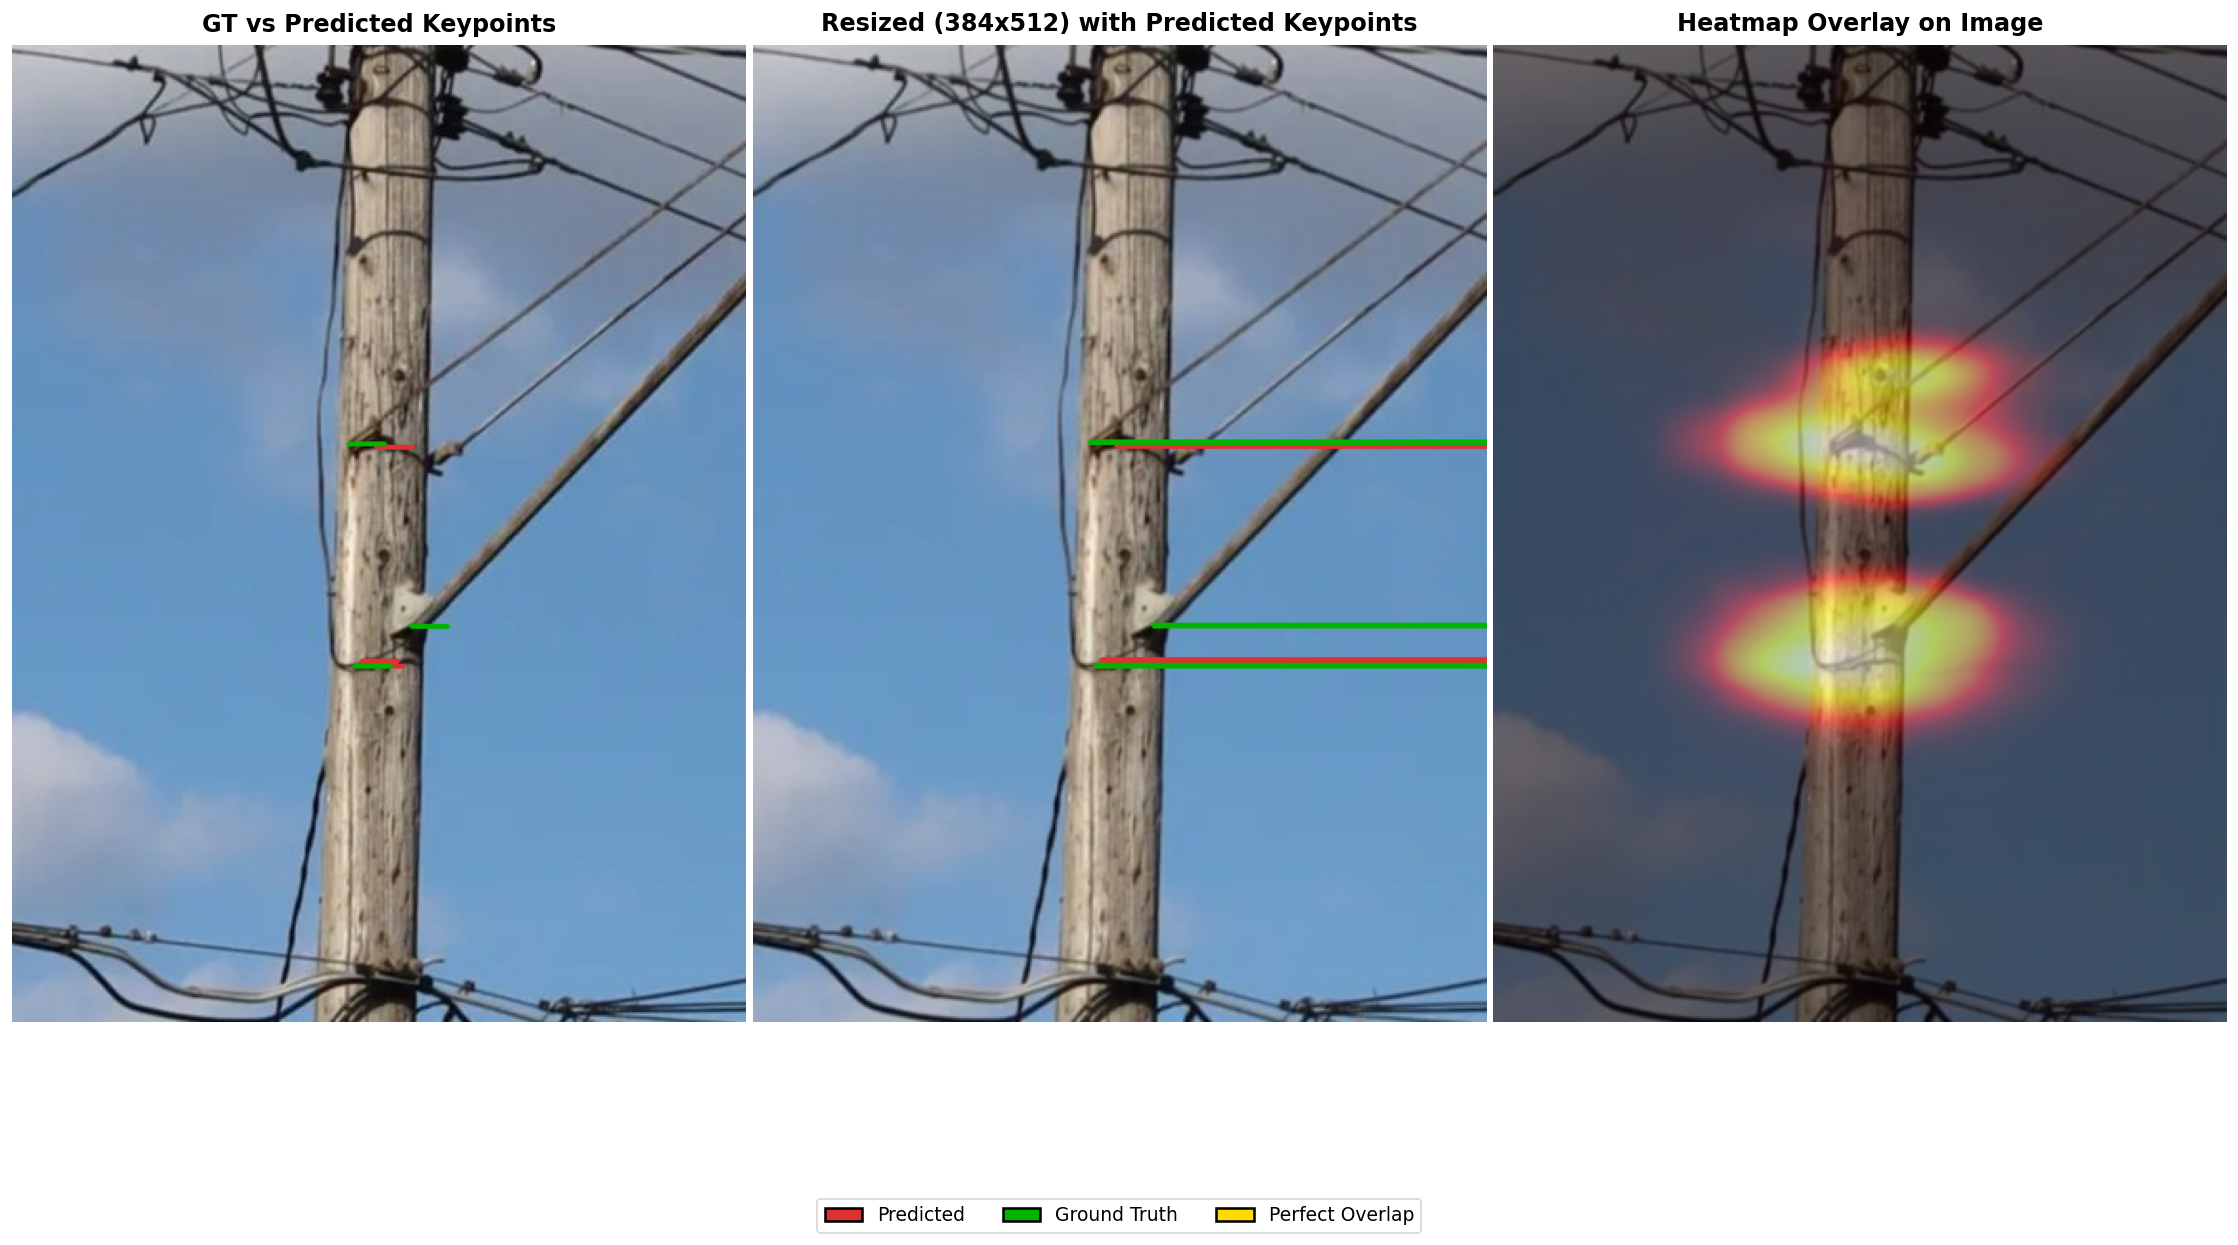

Image: MIBR032_071_1_Main_street_light1.jpg
Path: datasets/street_light_keypoint_detection/images/val/MIBR032_071_1_Main_street_light1.jpg
GT: 0 bboxes, 3 keypoints
Pred: 0 detections, 3 keypoints
  Pred kp 1: upper_bracket conf=0.900 error=0.304 in
  Pred kp 2: lower_bracket conf=0.888 error=3.329 in
  Pred kp 3: drip_loop conf=0.869 error=0.020 in


In [99]:
# Run Inference with Street Light Keypoint Detection Model on a Random Image in Test Dataset
from src.inference import load_keypoint_detector
from src.visualization import run_keypoint_detection_inference
from src.config import STREET_LIGHT_KEYPOINT_IMAGES_VAL, STREET_LIGHT_KEYPOINT_NAMES

kp_detector = load_keypoint_detector('street_light', device)

val_dir = STREET_LIGHT_KEYPOINT_IMAGES_VAL
run_keypoint_detection_inference(
    'street_light', kp_detector['model'], kp_detector['config'], kp_detector['preprocess'], val_dir,
    kp_detector['num_kp'], STREET_LIGHT_KEYPOINT_NAMES, KEYPOINT_COLORS, device
)

HRNet output channels: 256
✓ Riser keypoint detector loaded from runs/riser_keypoint_detection/weights/best.pth
Image: MNRV017_154_1_Main_riser1.jpg
Path: datasets/riser_keypoint_detection/images/val/MNRV017_154_1_Main_riser1.jpg
Image dimensions: 134x359

Running riser keypoint inference...


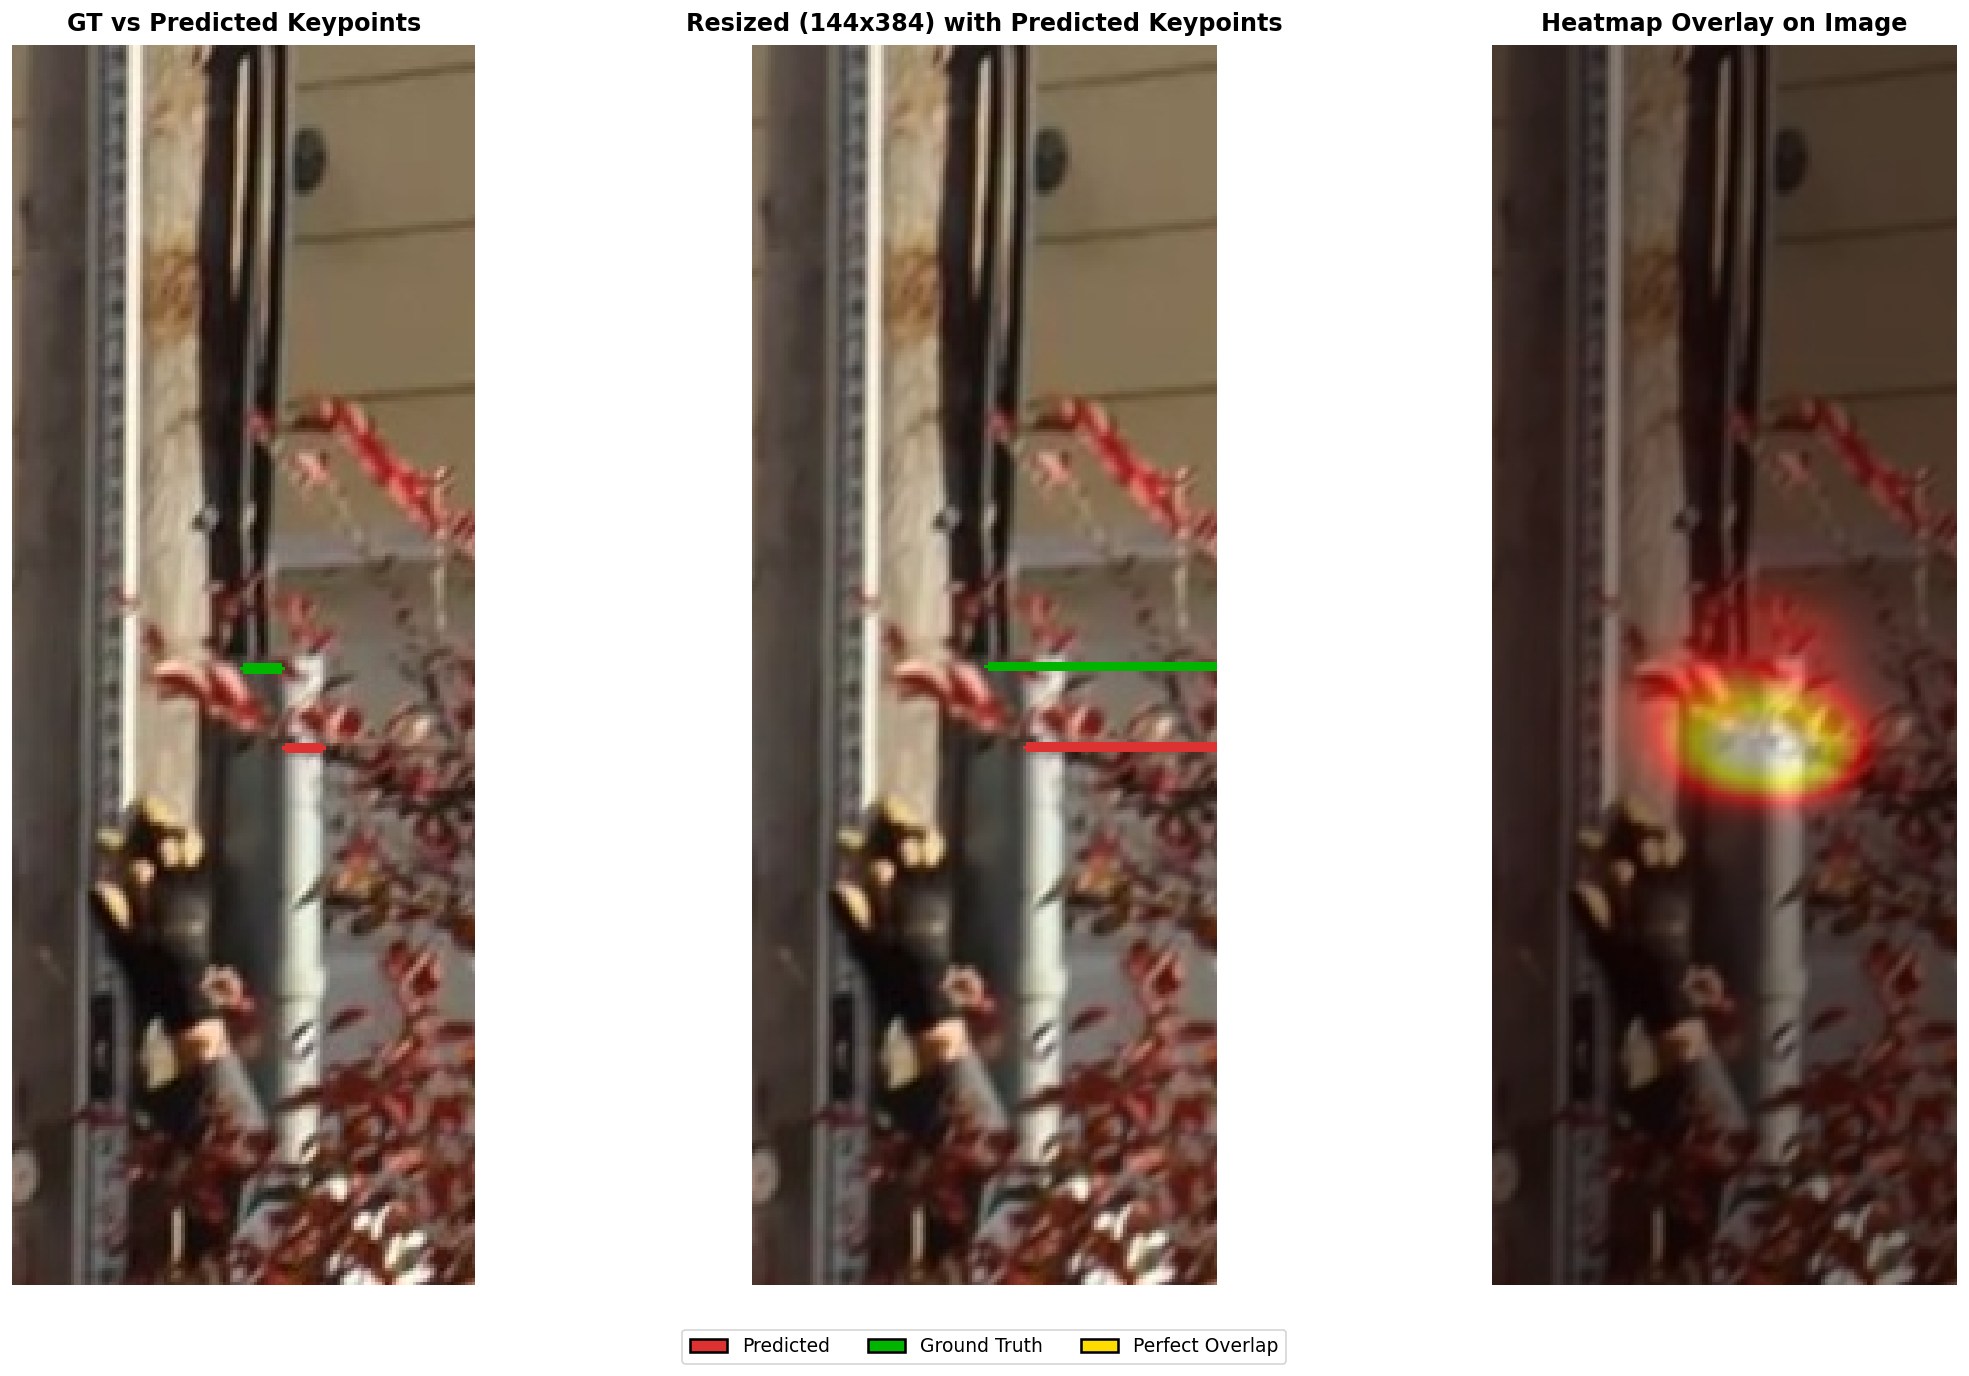

Image: MNRV017_154_1_Main_riser1.jpg
Path: datasets/riser_keypoint_detection/images/val/MNRV017_154_1_Main_riser1.jpg
GT: 0 bboxes, 1 keypoints
Pred: 0 detections, 1 keypoints
  Pred kp 1: top conf=0.842 error=3.117 in


In [120]:
# Run Inference with Riser Keypoint Detection Model on a Random Image in Test Dataset
from src.inference import load_keypoint_detector
from src.visualization import run_keypoint_detection_inference
from src.config import RISER_KEYPOINT_IMAGES_VAL, RISER_KEYPOINT_NAMES

kp_detector = load_keypoint_detector('riser', device)

val_dir = RISER_KEYPOINT_IMAGES_VAL
run_keypoint_detection_inference(
    'riser', kp_detector['model'], kp_detector['config'], kp_detector['preprocess'], val_dir,
    kp_detector['num_kp'], RISER_KEYPOINT_NAMES, KEYPOINT_COLORS, device
)

In [ ]:
# Equipment Pipeline: Pole -> 70% 2:5 crop -> Equipment -> Keypoints
from src.inference import load_pole_detector, load_equipment_detector, load_keypoint_detector
from src.inference_pipelines import equipment_pipeline
from src.config import EQUIPMENT_E2E_IMAGES_DIR

# Load models
pole_detector = load_pole_detector(device)
equip_detector = load_equipment_detector(device)
kp_models = {t: load_keypoint_detector(t, device) for t in ['riser', 'transformer', 'street_light', 'secondary_drip_loop']}

# Run on pole photos; GT from Labels/*_location.txt
equipment_pipeline.run(EQUIPMENT_E2E_IMAGES_DIR, pole_detector, equip_detector, kp_models,
                      EQUIPMENT_NAMES, EQUIPMENT_COLORS, KEYPOINT_COLORS, device)